# Phase 1: ingest and the three gates

This notebook calls the library. The logic lives in `hn_upvotes.data.ingest`,
`hn_upvotes.data.preprocess` and `hn_upvotes.data.gates`.

Run `make ingest` first. It writes `data/stories.parquet`.

Three gates, each of which changes a default in `target/normalise.BaselineConfig`:

1. Does the centre of `log1p(score)` drift by year?
2. Does the spread drift too?
3. How long does a score take to settle?

Plus the score distribution, the tokeniser comparison, and the leak audit.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from hn_upvotes.data import gates, ingest, preprocess

pd.set_option("display.width", 200)
STORIES = Path("../data/stories.parquet")
IMAGES = Path("../docs/img")

## What the pull cost

Measured from the Parquet footers before pulling anything. DuckDB pushes the column
projection into the reader, so only the eight projected columns cross the network.

In [2]:
con = ingest.connect()
sizes = ingest.projected_transfer_bytes(con)
con.close()

wanted = sizes.column_name.isin(ingest.PROJECTED_COLUMNS)
projected = int(sizes.loc[wanted, "compressed_bytes"].sum())
total = int(sizes.compressed_bytes.sum())
print(f"all 16 columns   {total:>15,} bytes  ({total / 1000**3:.2f} GB)")
print(f"projected 8      {projected:>15,} bytes  ({projected / 1000**3:.2f} GB)")
print(f"share pulled     {projected / total:>15.1%}")
sizes

all 16 columns    11,930,610,821 bytes  (11.93 GB)
projected 8          775,563,753 bytes  (0.78 GB)
share pulled                6.5%


,column_name,compressed_bytes
0,text,6184534390
1,words,4665128064
2,id,178918449
3,url,159388850
4,parent,158432748
5,by,148176365
6,title,147876518
7,kids,142483722
8,time,119549642
9,score,11302000


## The ingested table

The usable row count is a measurement. The plan expected "roughly 4M to 6M", which was
an expectation, not a number anyone had checked.

In [3]:
stories = pd.read_parquet(STORIES)
print(f"usable stories      {len(stories):>12,}")
print(f"items in the dump   {49_119_480:>12,}")
print(f"kept                {len(stories) / 49_119_480:>12.2%}")
print(f"range               {stories.time.min()} to {stories.time.max()}")
stories.head()

usable stories         4,738,004
items in the dump     49,119,480
kept                       9.65%
range               2006-10-09 18:21:51 to 2026-08-05 23:54:15


,id,type,time,title,score,by,url,descendants
0,1,1,2006-10-09 18:21:51,Y Combinator,57,pg,http://ycombinator.com,15
1,2,1,2006-10-09 18:30:28,A Student's Guide to Startups,16,phyllis,http://www.paulgraham.com/mit.html,0
2,3,1,2006-10-09 18:40:33,Woz Interview: the early days of Apple,7,phyllis,http://www.foundersatwork.com/stevewozniak.html,0
3,4,1,2006-10-09 18:47:42,NYC Developer Dilemma,5,onebeerdave,http://avc.blogs.com/a_vc/2006/10/the_nyc_deve...,0
4,5,1,2006-10-09 18:51:04,"Google, YouTube acquisition announcement could...",7,perler,http://www.techcrunch.com/2006/10/09/google-yo...,0


### Scores that are not final

Two windows of months record the score at submission rather than after the post
finished scoring. Found by refetching a sample from the live HN API. Their scores
cannot be used as labels, so every gate below runs on the rest.

In [4]:
settled = ingest.drop_unsettled_months(stories)
print(f"all stories       {len(stories):>12,}")
print(f"settled scores    {len(settled):>12,}")
dropped = len(stories) - len(settled)
print(f"dropped           {dropped:>12,}  ({dropped / len(stories):.1%})")
print(f"excluded months   {len(ingest.UNSETTLED_SCORE_MONTHS)}")
print(sorted(ingest.UNSETTLED_SCORE_MONTHS))

all stories          4,738,004
settled scores       4,168,189
dropped                569,815  (12.0%)
excluded months   21
['2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08']


In [5]:
# The signature that found them: mean log1p(score) per month is cleanly bimodal.
monthly = (
    stories.assign(month=stories.time.dt.strftime("%Y-%m"), y=np.log1p(stories.score))
    .groupby("month")
    .agg(n=("score", "size"), mean_log1p=("y", "mean"))
)
populated = monthly[monthly.n >= 1000]
print(f"months below 1.10 : {(populated.mean_log1p < 1.10).sum()}")
print(f"months above 1.26 : {(populated.mean_log1p > 1.26).sum()}")
print(f"months in between : {populated.mean_log1p.between(1.10, 1.26, inclusive='neither').sum()}")
populated[populated.mean_log1p < 1.26].round(3)

months below 1.10 : 20
months above 1.26 : 213
months in between : 1


,n,mean_log1p
month,,
2022-12,26287,0.993
2023-01,27903,0.979
2023-02,24701,0.989
2023-03,28315,0.986
2023-04,26088,0.981
2023-05,27217,0.984
2023-06,26339,1.002
2023-07,26575,0.993
2023-08,27528,0.987


## Gate 1: does the centre drift by year?

If it is flat, the target transform is unjustified and reduces to plain `log1p(score)`.

In [6]:
yearly = gates.yearly_score_stats(settled)
yearly = yearly[yearly.n >= 10_000].reset_index(drop=True)  # 2006 has 45 rows
yearly.round(4)

,year,n,median,mean,std,q25,q75,iqr,median_raw_score
0,2007,21663,1.0986,1.4324,0.7871,0.6931,1.9459,1.2528,2.0
1,2008,61555,1.0986,1.4898,0.9164,0.6931,1.9459,1.2528,2.0
2,2009,88266,1.0986,1.6237,1.1009,0.6931,2.1972,1.5041,2.0
3,2010,140523,1.0986,1.6169,1.1386,0.6931,1.9459,1.2528,2.0
4,2011,199034,1.0986,1.5364,1.1265,0.6931,1.7918,1.0986,2.0
5,2012,232700,1.0986,1.4367,1.0994,0.6931,1.6094,0.9163,2.0
6,2013,260483,1.0986,1.4312,1.1129,0.6931,1.6094,0.9163,2.0
7,2014,247407,1.0986,1.4876,1.1213,0.6931,1.6094,0.9163,2.0
8,2015,265015,1.0986,1.5324,1.1423,0.6931,1.7918,1.0986,2.0
9,2016,283417,1.0986,1.5168,1.1403,0.6931,1.6094,0.9163,2.0


distinct median log1p values, 2007-2024: [1.09861229]
log1p(2) = 1.0986
2025 median = 1.3863 = log1p(3)


PosixPath('../docs/img/gate1-median-by-year.png')

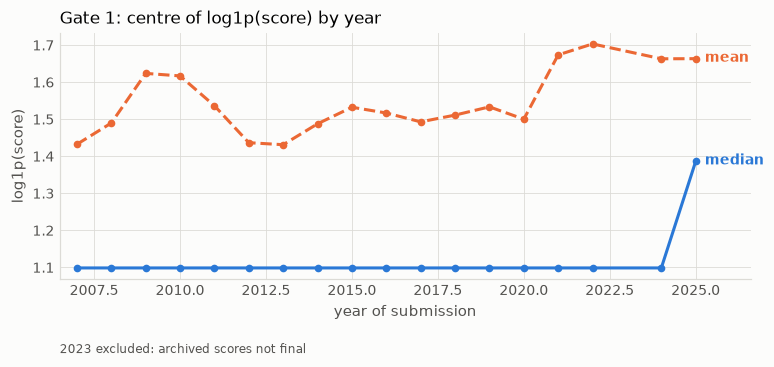

In [7]:
flat_years = yearly[(yearly.year >= 2007) & (yearly.year <= 2024)]
print("distinct median log1p values, 2007-2024:", flat_years["median"].unique())
print(f"log1p(2) = {np.log1p(2):.4f}")
print(f"2025 median = {yearly.loc[yearly.year == 2025, 'median'].iloc[0]:.4f} = log1p(3)")
gates.plot_yearly_centre(yearly, IMAGES / "gate1-median-by-year.png")

![gate 1](../docs/img/gate1-median-by-year.png)

**Answer: no.** The median takes exactly one value, `log1p(2)`, for eighteen consecutive
years. So `BaselineConfig.centre` becomes `"zero"`.

## Gate 2: does the spread drift too?

std  1.1386 -> 1.1721   ratio 1.029   year correlation +0.763
iqr  1.2528 -> 0.8473   ratio 0.676   year correlation -0.098


PosixPath('../docs/img/gate2-spread-by-year.png')

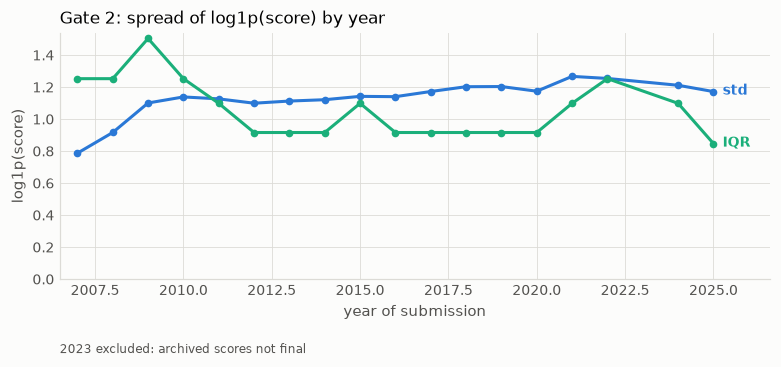

In [8]:
era = yearly[yearly.n >= 100_000]  # 2010 onward, every year with a six-figure count
for column in ["std", "iqr"]:
    first, last = era[column].iloc[0], era[column].iloc[-1]
    r = np.corrcoef(era.year, era[column])[0, 1]
    print(
        f"{column:4s} {first:.4f} -> {last:.4f}   "
        f"ratio {last / first:.3f}   year correlation {r:+.3f}"
    )
gates.plot_yearly_spread(yearly, IMAGES / "gate2-spread-by-year.png")

![gate 2](../docs/img/gate2-spread-by-year.png)

**Answer: no.** The standard deviation moves 2.9% over sixteen years and the
interquartile range moves the other way. So `BaselineConfig.scale` becomes `False`, and
the forward transform reduces to plain `log1p(score)`.

### Where the drift actually is

The centre and the bulk spread are flat. The extreme tail is not. No statistic the
transform uses would have caught this, which is the honest reason the transform comes
out rather than a reason to keep it.

In [9]:
quantiles = (
    settled.assign(year=settled.time.dt.year)
    .groupby("year")
    .score.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
    .unstack()
)
quantiles.columns = ["p50", "p75", "p90", "p95", "p99", "p99.9"]
quantiles = quantiles.loc[2007:2025]
print("raw score quantiles, 2007 against 2025")
for column in quantiles.columns:
    a, b = quantiles.loc[2007, column], quantiles.loc[2025, column]
    print(f"  {column:6s} {a:8.1f} -> {b:8.1f}   x{b / a:.2f}")
quantiles.round(1)

raw score quantiles, 2007 against 2025
  p50         2.0 ->      3.0   x1.50
  p75         6.0 ->      6.0   x1.00
  p90        13.0 ->     26.0   x2.00
  p95        19.0 ->     89.0   x4.68
  p99        38.0 ->    355.0   x9.34
  p99.9      89.4 ->   1000.7   x11.20


,p50,p75,p90,p95,p99,p99.9
year,,,,,,
2007,2.0,6.0,13.0,19.0,38.0,89.4
2008,2.0,6.0,18.0,30.0,66.0,148.4
2009,2.0,8.0,29.0,49.0,111.0,252.7
2010,2.0,6.0,33.0,63.0,158.0,356.0
2011,2.0,5.0,27.0,68.0,207.0,526.0
2012,2.0,4.0,20.0,64.0,214.0,545.3
2013,2.0,4.0,20.0,69.0,233.0,601.0
2014,2.0,4.0,22.0,72.0,232.0,603.0
2015,2.0,5.0,27.0,71.0,227.0,597.0


## Gate 3: how long does a score take to settle?

The brief's method reads a story's age at observation as `committed_at - time`, using
the dataset's own `stats.csv`. That premise does not hold here: the months whose ages
would be young enough to measure are exactly the months whose scores were captured at
submission. So the same method runs against a live read instead, where the observation
instant is true by construction.

**Caveat, unchanged from the brief: these are different posts at different ages, not the
same post tracked over time.**

In [10]:
commit_times = ingest.load_commit_times()
month_end = pd.to_datetime(commit_times.month) + pd.offsets.MonthEnd(1) + pd.Timedelta(days=1)
commit_times["lag_days"] = (commit_times.committed_at - month_end).dt.total_seconds() / 86400
print(f"committed months                        {len(commit_times)}")
print(f"committed at their own month boundary   {(commit_times.lag_days <= 2).sum()}")
backfilled = (commit_times.committed_at.dt.date.astype(str) == "2026-03-14").sum()
print(f"backfilled on 2026-03-14                {backfilled}")
commit_times.tail(10)

committed months                        239
committed at their own month boundary   6
backfilled on 2026-03-14                231


,month,lowest_id,highest_id,count,size_bytes,committed_at,lag_days
229,2025-11,45778034,46101788,323748,46520346,2026-03-14 15:51:33,103.660799
230,2025-12,46101789,46449678,347597,57302489,2026-03-14 15:52:20,72.661343
231,2026-01,46449679,46842175,392216,101771492,2026-03-14 15:54:07,41.662581
232,2026-02,46842176,47201952,359707,92692621,2026-03-14 15:54:30,13.662847
233,2026-03,47201953,47595034,391664,162171298,2026-04-01 00:00:39,0.000451
234,2026-04,47595075,47969846,374618,147432870,2026-05-01 00:01:26,0.000995
235,2026-05,47969881,48351048,381075,148476358,2026-06-01 00:01:13,0.000845
236,2026-06,48351087,48740762,389561,151615757,2026-07-01 00:00:21,0.000243
237,2026-07,48740813,49129809,388913,150071886,2026-08-01 00:00:24,0.000278
238,2026-08,49129847,49190660,60733,24324087,2026-08-06 00:00:16,-25.999815


In [11]:
# Recent stories, whose current scores are read from the live HN API in one pass.
# 2026-08 covers ages up to ~126h; a sample of 2026-07 supplies the settled reference.
recent = stories[stories.time >= "2026-07-01"]
young = recent[recent.time >= "2026-08-01"]
older = recent[recent.time < "2026-08-01"].sample(9000, random_state=0)
pool = pd.concat([young, older], ignore_index=True)[["id", "time"]]

live, observed_at = gates.fetch_live_scores(pool.id)
print(f"read {len(live):,} live scores at {observed_at} UTC")
ages = gates.live_observation_ages(pool, live, observed_at)
print(f"ages from {ages.age_hours.min():.1f}h to {ages.age_hours.max():.0f}h")

read 13,852 live scores at 2026-08-06 06:22:45.327370 UTC
ages from 6.5h to 870h


PosixPath('../docs/img/gate3-settling-curve.png')

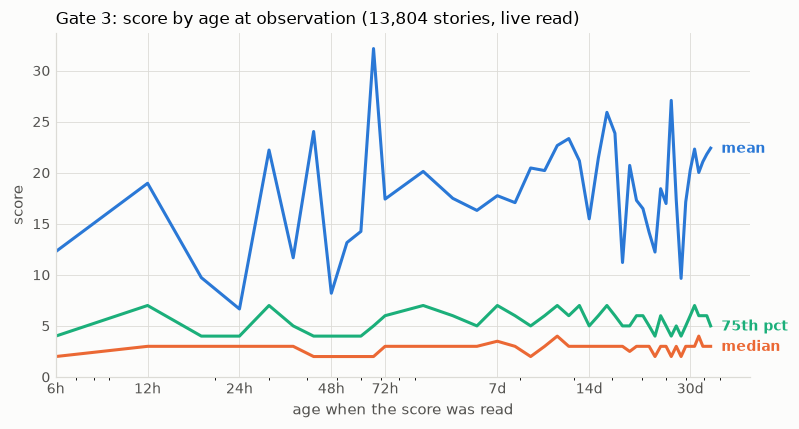

In [12]:
curve = gates.settling_curve(ages, min_bucket_n=60, statistic="median_score", bucket_hours=6.0)
gates.plot_settling_curve(curve, IMAGES / "gate3-settling-curve.png")

,band,low_hours,high_hours,n,hours_of_day,mean_log1p,ci_low,ci_high
0,0-12h,0.0,12.0,252,6,1.490,1.377,1.603
1,12-24h,12.0,24.0,693,13,1.733,1.662,1.816
2,24-48h,24.0,48.0,1238,24,1.656,1.597,1.719
3,48-72h,48.0,72.0,1096,24,1.534,1.467,1.603
4,72-168h,72.0,168.0,2196,24,1.782,1.732,1.829
5,>=14d,336.0,inf,6300,24,1.683,1.656,1.712


PosixPath('../docs/img/gate3-settling-bands.png')

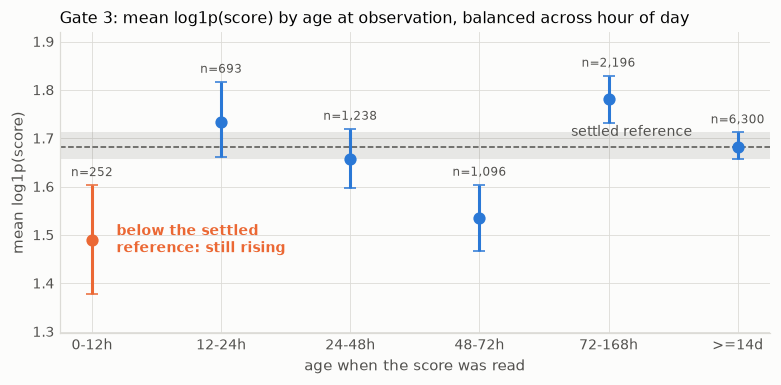

In [13]:
bands = gates.settling_bands(ages)
display(bands.round(3))
gates.plot_settling_bands(bands, IMAGES / "gate3-settling-bands.png")

![gate 3 curve](../docs/img/gate3-settling-curve.png)

![gate 3 bands](../docs/img/gate3-settling-bands.png)

**Answer: between 12 and 24 hours.** Only the 0 to 12 hour band sits below the settled
reference with a clear gap. The 12 to 24 hour band already overlaps it. Later bands
wander above and below by more than their intervals, which is day-to-day cohort
variation, not settling. So `BaselineConfig.lag` becomes 24 hours, down from 48.

## The score distribution and the floor spike

The plan claims a large share of posts score 1 or 2 and that the spike survives the log
transform. This confirms or refutes it, and decides whether percentile rank is worth
reporting as a secondary readout.

,score,n,share,log1p_score,cumulative_share
0,1,1372666,0.3293,0.6931,0.3293
1,2,1027583,0.2465,1.0986,0.5758
2,3,488649,0.1172,1.3863,0.6931
3,4,236224,0.0567,1.6094,0.7498
4,5,133714,0.0321,1.7918,0.7818


share at 1 or 2 points: 57.6%


PosixPath('../docs/img/score-distribution.png')

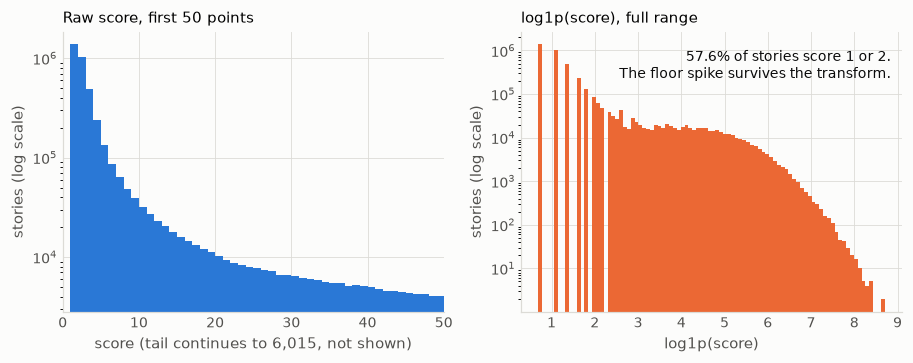

In [14]:
floor = gates.score_floor_share(settled)
display(floor.round(4))
print(f"share at 1 or 2 points: {floor.cumulative_share.iloc[1]:.1%}")
gates.plot_score_distribution(settled, IMAGES / "score-distribution.png")

![score distribution](../docs/img/score-distribution.png)

**Confirmed.** The spike is at the floor in both panels: `log1p` is monotone, so it
cannot spread a point mass. Percentile rank stays a secondary readout only.

## Tokeniser: the dump's `words` column against ours

In [15]:
sample = ingest.load_words_sample("2026-06")
titled = sample[(sample.type == ingest.STORY_TYPE_CODE)]
month_stories = int((stories.time.dt.strftime("%Y-%m") == "2026-06").sum())
print(f"titled stories in 2026-06              {month_stories:>8,}")
share = len(titled) / month_stories
print(f"of those, carrying a `words` entry     {len(titled):>8,}  ({share:.1%})")
print(f"of those, that also carry `text`       {(titled.text != '').sum():>8,}")
print()
print("`words` is sorted and deduplicated, so word order is gone:")
row = sample[sample.type == 2].iloc[0]
print("  text :", row.text[:70])
print("  words:", list(row.words)[:10])

titled stories in 2026-06                30,102
of those, carrying a `words` entry        2,474  (8.2%)
of those, that also carry `text`          2,446

`words` is sorted and deduplicated, so word order is gone:
  text : You might as well be arguing for gambling as a form of leisure. That&#
  words: ['a', 'arguing', 'as', 'be', 'being', 'but', 'by', 'delude', 'don', 'for']


In [16]:
import collections

shared = sample[sample.text != ""].sample(5000, random_state=0)
intersection = union = exact = 0
ours_only: collections.Counter = collections.Counter()
for _, r in shared.iterrows():
    theirs = set(r.words)
    ours = set(preprocess.tokenise(preprocess.normalise_title(r.text)))
    intersection += len(theirs & ours)
    union += len(theirs | ours)
    exact += theirs == ours
    ours_only.update(ours - theirs)

print(f"micro Jaccard    {intersection / union:.3f}")
print(f"exact set match  {exact / len(shared):.1%}")


def classify(token: str) -> str:
    if "'" in token:
        return "contraction"
    if "-" in token:
        return "hyphenated"
    if token in {"href", "rel", "nofollow", "p", "a", "i", "pre", "code"}:
        return "html markup"
    return "other"


classes: collections.Counter = collections.Counter()
for token, count in ours_only.items():
    classes[classify(token)] += count
total_ours_only = sum(classes.values())
for name, count in classes.most_common():
    print(f"  {name:14s} {count:7,}  {count / total_ours_only:6.1%}")

micro Jaccard    0.899
exact set match  32.9%
  contraction      4,675   42.1%
  html markup      3,782   34.0%
  hyphenated       2,021   18.2%
  other              634    5.7%


**The project uses its own tokeniser.** `words` covers `text`, not `title`, and it is a
sorted set rather than a sequence, so it cannot feed a context window. On the input they
share they agree closely; where they differ, `words` splits contractions and hyphens,
which on Hacker News breaks up the content words.

## Leak audit

Run against the real ingested frame's columns, not a synthetic list.

In [17]:
from hn_upvotes.features.schema import (
    LeakedFeatureError,
    leaked_columns_present,
    validate_feature_set,
)

columns = list(stories.columns)
print("ingested columns:", columns)
print("leaked columns present:", sorted(leaked_columns_present(columns)))

try:
    validate_feature_set(columns)
except LeakedFeatureError as error:
    print("\nREJECTED, as it must be:\n ", error)
else:
    raise AssertionError("the allowlist accepted a frame containing post-hoc columns")

ingested columns: ['id', 'type', 'time', 'title', 'score', 'by', 'url', 'descendants']
leaked columns present: ['descendants', 'score']

REJECTED, as it must be:
  post-hoc columns cannot be features: ['descendants', 'score']. These are consequences of the post going live, not inputs available at submission time.


In [18]:
# `kids` is absent by construction. Both halves are asserted: that it is not in the
# frame, and that the allowlist would still refuse it if a later phase added it.
assert "kids" not in columns
print("`kids` in the ingested frame:", "kids" in columns)

try:
    validate_feature_set(["title", "by", "url", "time", "kids"])
except LeakedFeatureError as error:
    print("would still be rejected:\n ", error)
else:
    raise AssertionError("the allowlist accepted `kids`")

print("\nthe legal feature set:", sorted(validate_feature_set(["title", "by", "url", "time"])))

`kids` in the ingested frame: False
would still be rejected:
  post-hoc columns cannot be features: ['kids']. These are consequences of the post going live, not inputs available at submission time.

the legal feature set: ['by', 'time', 'title', 'url']


## What changed in the code

Every gate changed a default. That is the point of the phase.

In [19]:
from hn_upvotes.target.normalise import BaselineConfig

config = BaselineConfig()
print(f"centre  {config.centre!r:10s}  was 'mean'   (gate 1)")
print(f"scale   {config.scale!r:10}  was True     (gate 2)")
print(f"lag     {str(config.lag):10s}  was 48:00:00 (gate 3)")
print(f"window  {str(config.window):10s}  unchanged")
print(f"spread  {config.spread!r:10s}  unchanged, unused while scale is False")

centre  'zero'      was 'mean'   (gate 1)
scale   False       was True     (gate 2)
lag     1 day, 0:00:00  was 48:00:00 (gate 3)
window  30 days, 0:00:00  unchanged
spread  'std'       unchanged, unused while scale is False
